# Pairs Trading — one notebook, all six milestones

Find two stocks that move together, trade the gap between them, and score the result honestly.

**The bet:** two related companies drift apart, then snap back. You short the expensive one and buy
the cheap one, and you profit when the gap closes — regardless of whether the market went up or down.

Order of work:

| Milestone | Question it answers | Function |
|---|---|---|
| 1 | How many shares of B hedge one share of A? | `hedge_ratio` |
| 2 | Are these two actually tied together? | `engle_granger_pvalue` |
| 3 | Which pairs in my universe qualify? | `find_cointegrated_pairs` |
| 4 | When do I buy and sell? | `compute_spread`, `rolling_zscore`, `generate_positions` |
| 5 | Did it make money after costs? | `backtest_pair`, `sharpe_ratio`, `max_drawdown`, `summarize` |
| 6 | Does it work on data I didn't pick it on? | the driver at the bottom |

Run the cells top to bottom. Everything above milestone 6 is pure function definitions with no
side effects, which is what lets `pytest` import them.

In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from itertools import combinations
from pathlib import Path
from statsmodels.tsa.stattools import adfuller

TRADING_DAYS = 252   # trading days in a year, used to annualize the Sharpe ratio

## Milestone 1 — the hedge ratio

Two stocks rarely move one-for-one. If A moves \$2.50 every time B moves \$1.00, then holding one
share of A against one share of B leaves you badly unbalanced.

`beta` is that exchange rate. We get it by fitting a straight line through a scatter plot of the two
prices: `A = alpha + beta * B`. The slope is beta.

**Why the intercept (`alpha`) matters:** one stock might trade at \$300 and the other at \$30. That
gap in *level* has nothing to do with how they move *together*. `sm.add_constant` adds a column of
1s so the line is free to sit at whatever height it needs, leaving the slope to describe only the
relationship. Force the line through the origin and the level difference contaminates beta.

**Argument order is the whole game here.** `hedge_ratio(y, x)` means *regress y on x* — y is the
thing being explained, x is the explainer. Swap them and you get a different, wrong number.

In [2]:
# finding beta
def hedge_ratio(y: pd.Series, x: pd.Series) -> float:
    model = sm.OLS(y, sm.add_constant(x)).fit()
    return float(model.params.iloc[1])   # params = [intercept, slope]; we want the slope (beta)

## Milestone 2 — is this pair real?

Now the key question: **are these two genuinely tied together, or did they just happen to wander
in the same direction for a while?**

The dangerous trap is correlation. Two stocks can have near-perfect correlation of daily *returns*
and still end up hundreds of dollars apart, because correlation says nothing about the gap staying
bounded. What we need is **cointegration**: proof that some combination of the prices keeps
returning to a fixed average.

The Engle-Granger method is two steps:

1. Fit the line, take `spread = y - beta*x`. If the pair is real, the wandering cancels out and the
   leftover is flat noise.
2. Run an **Augmented Dickey-Fuller (ADF)** test on that spread.

**How to read the p-value.** ADF starts from the assumption "this series is a random walk that never
has to come back" — that's the null hypothesis, the boring explanation. The p-value is the chance of
seeing data this mean-reverting *if the boring explanation were true*. A tiny p-value means the boring
explanation doesn't fit, so we reject it. Think innocent-until-proven-guilty: p < 0.05 is the evidence
needed to convict.

- `regression="c"` — allow the spread a non-zero average, but no trend. A spread that trends isn't
  something you can trade as a mean reverter.
- `autolag="AIC"` — let the test pick how many lags to include instead of guessing.

In [3]:
# ADF test for cointegration and flatness
def engle_granger_pvalue(y: pd.Series, x: pd.Series) -> float:
    df = pd.concat([y, x], axis=1).dropna()
    y_aligned, x_aligned = df.iloc[:, 0], df.iloc[:, 1]
    # cleaned and aligned: same dates on both legs, no gaps

    beta = hedge_ratio(y_aligned, x_aligned)
    spread = y_aligned - beta * x_aligned

    return float(adfuller(spread, regression="c", autolag="AIC")[1])   # [1] is the p-value

## Milestone 3 — search the whole universe

Milestones 1 and 2 judge one pair you already chose. In reality nobody hands you the pair, so this
is the search: try every possible pairing, score each, keep the winners, rank them.

`combinations(cols, 2)` yields each unordered pair exactly once — `(A,B)` but never `(B,A)` or
`(A,A)`. With n tickers that's `n*(n-1)/2` pairs.

**The trap to write down.** 12 tickers is 66 tests. At a 5% threshold roughly **3 pairs pass by pure
luck** even if nothing is genuinely related. 50 tickers is 1,225 tests and ~61 lucky passes. This is
the multiple-comparisons problem: search hard enough and you *will* find coincidences, and they'll
sit at the top of your ranking looking like your best ideas. A low p-value here is a hint to
investigate, never proof.

In [4]:
def find_cointegrated_pairs(prices: pd.DataFrame, max_pvalue: float = 0.05) -> pd.DataFrame:
    rows = []

    for a, b in combinations(prices.columns, 2):
        y, x = prices[a], prices[b]
        rows.append({
            "a": a,
            "b": b,
            "pvalue": engle_granger_pvalue(y, x),
            "beta": hedge_ratio(y, x),
        })

    result = pd.DataFrame(rows, columns=["a", "b", "pvalue", "beta"])
    result = result[result["pvalue"] <= max_pvalue]        # drop the ones that failed the test
    return result.sort_values("pvalue").reset_index(drop=True)   # best first, renumber 0,1,2...

## Getting price data

Downloads adjusted close prices and caches them to a local CSV, because Yahoo rate-limits hard and
re-downloading the same data every run is slow and rude.

Adjusted closes are back-corrected for splits and dividends, which is what you need for return
maths — otherwise a 2-for-1 split looks like the stock halving.

**Know the limitation:** Yahoo only lists companies that still exist. Every firm that went bankrupt
or got acquired is silently missing, so your universe is biased toward survivors. Fine for learning,
useless for anything real.

In [5]:
def _project_root() -> Path:
    # walk up from wherever Jupyter was launched until we find the folder holding pytest.ini
    here = Path.cwd()
    for candidate in [here, *here.parents]:
        if (candidate / "pytest.ini").exists():
            return candidate
    return here


CACHE_DIR = _project_root() / "data"


def load_prices(tickers: list[str], start: str, end: str, cache: bool = True) -> pd.DataFrame:
    cache_file = CACHE_DIR / f"{'_'.join(sorted(tickers))}_{start}_{end}.csv"

    if cache and cache_file.exists():
        prices = pd.read_csv(cache_file, index_col=0, parse_dates=True)
    else:
        import yfinance as yf

        raw = yf.download(tickers, start=start, end=end, auto_adjust=True, progress=False)
        prices = raw["Close"]
        if isinstance(prices, pd.Series):        # a single ticker comes back as a Series
            prices = prices.to_frame(tickers[0])
        if cache:
            CACHE_DIR.mkdir(exist_ok=True)
            prices.to_csv(cache_file)

    return prices.dropna(how="any")   # drop days where any leg is missing, so dates line up

## Milestone 4 — turning the spread into trades

Three steps: build the spread, decide what counts as "unusually far apart", then decide when to be
in a trade.

### Why a *rolling* z-score

A gap of \$10 is enormous for one pair and nothing for another, so we measure in standard
deviations instead of dollars:

```
z = (spread - average of last 60 days) / (std dev of last 60 days)
```

z = 2 means "further apart than usual". z = 0 means "back to normal".

The word **rolling** is doing critical work. If you used the average of the *whole* series, then your
signal on day 100 would be built from prices in day 900 — information you could not possibly have had.
That's **lookahead bias**, and it's the number one way beginners build a strategy that prints money
on paper and loses it in reality. `.rolling(60)` only ever looks backwards.

The first 59 values come out `NaN`. That's correct and honest — you don't have 60 days of history yet.

### Why positions need a loop

The rules have **hysteresis**: you enter at |z| = 2.0 but don't leave until |z| = 0.5. So at z = 1.2
the right action depends on whether you're already in a trade. That's a state machine — it needs
memory, so a simple `np.sign(z) * (abs(z) > 2)` cannot express it.

The dead zone between 0.5 and 2.0 is deliberate. It stops you from re-entering on noise the moment
after you take profit.

In [6]:
def compute_spread(y: pd.Series, x: pd.Series, beta: float) -> pd.Series:
    # the tradeable object: neither leg is stable alone, but this combination is
    return y - beta * x


def rolling_zscore(spread: pd.Series, window: int = 60) -> pd.Series:
    rolling = spread.rolling(window)                      # window ENDS at t -> only past data
    return (spread - rolling.mean()) / rolling.std()      # first window-1 values are NaN, correctly


def generate_positions(zscore: pd.Series, entry: float = 2.0, exit: float = 0.5) -> pd.Series:
    positions = np.zeros(len(zscore), dtype=int)
    state = 0     # our memory: +1 long the spread, -1 short it, 0 flat

    for i, z in enumerate(zscore.to_numpy(dtype=float)):
        if np.isnan(z):
            state = 0                      # warm-up period: stay out
        elif state == 0:
            if z > entry:
                state = -1                 # spread too wide -> short it, expect it to narrow
            elif z < -entry:
                state = 1                  # spread too narrow -> long it, expect it to widen
        elif state == 1:
            if z >= -exit:
                state = 0                  # reverted far enough, take the profit
        else:
            if z <= exit:
                state = 0
        positions[i] = state

    return pd.Series(positions, index=zscore.index, dtype=int)

## Milestone 5 — scoring it honestly

This is where backtests lie, so read the two guard rails carefully.

### Guard rail 1: `.shift(1)`

You see today's closing price, work out the z-score, and decide to trade. **You cannot buy at that
same closing price** — it already happened. You trade tomorrow.

`positions.shift(1)` moves every decision forward one day, so today's profit comes from the position
you were already holding. Delete that one call and every backtest suddenly looks brilliant, because
you're buying on exactly the days you already know things went up. It is the single most common bug
in amateur quant work.

### Guard rail 2: costs on position *changes*

You pay when shares actually move. Going flat → long trades one unit; flipping long → short trades
two, so it costs double. `positions.diff()` gives the size of each change, and we charge on the
absolute value.

### The return formula

```
r = yesterday's position * (return of y - return of x) / 2
```

Half the money in each leg, so `r` is the return on the whole account. Note beta doesn't appear —
it shapes the *signal*, but a properly beta-weighted book needs daily rebalancing whose weights
drift and whose trades cost money. Equal dollars is the standard simplification.

### The three numbers

- **Sharpe ratio** — return per unit of wobble, annualized. Above 1 is good, below 0.5 is noise.
- **Max drawdown** — the worst peak-to-trough fall. Sharpe treats up and down alike; drawdown asks
  the question a real investor asks, which is "how bad did it get?" A strategy can have a fine Sharpe
  and still be unholdable.
- **Round trips** — how many completed trades. If it's 3, your metrics rest on 3 observations and
  mean nothing.

In [7]:
def backtest_pair(y: pd.Series, x: pd.Series, beta: float,
                  positions: pd.Series, cost_bps: float = 5.0) -> pd.DataFrame:
    x = x.reindex(y.index)                             # force both legs onto the same dates
    positions = positions.reindex(y.index).fillna(0)

    ret_y = y.pct_change()
    ret_x = x.pct_change()

    lagged = positions.shift(1)                        # decide today, trade tomorrow
    ret = (lagged * (ret_y - ret_x) / 2.0).fillna(0.0)

    turnover = positions.diff()
    turnover.iloc[0] = positions.iloc[0]               # before day 1 we were flat
    cost = turnover.abs() * (cost_bps / 10_000.0)      # bps -> decimal

    ret_net = ret - cost
    equity = (1.0 + ret_net).cumprod()                 # growth of $1

    return pd.DataFrame({"ret": ret, "ret_net": ret_net, "equity": equity}, index=y.index)


def sharpe_ratio(daily_returns: pd.Series) -> float:
    r = daily_returns.dropna()
    if len(r) < 2:
        return 0.0
    sd = r.std(ddof=1)
    if sd == 0 or np.isnan(sd):
        return 0.0                                      # no wobble -> avoid dividing by zero
    return float(r.mean() / sd * np.sqrt(TRADING_DAYS))


def max_drawdown(equity: pd.Series) -> float:
    eq = equity.dropna()
    if eq.empty:
        return 0.0
    drawdown = eq / eq.cummax() - 1.0                   # how far below the best-ever level
    return float(drawdown.min())


def summarize(result: pd.DataFrame, positions: pd.Series) -> dict:
    equity = result["equity"].dropna()
    total_return = float(equity.iloc[-1] - 1.0) if not equity.empty else 0.0

    pos = positions.reindex(result.index).fillna(0)
    prev = pos.shift(1).fillna(0)
    n_round_trips = int(((prev != 0) & (pos == 0)).sum())   # count nonzero -> flat transitions

    return {
        "total_return": total_return,
        "sharpe": sharpe_ratio(result["ret_net"]),
        "max_drawdown": max_drawdown(result["equity"]),
        "n_round_trips": n_round_trips,
    }

## Milestone 6 — the real test

Everything above is just definitions. Now we point it at actual market data.

**The one rule that makes this honest:** we search for pairs on 2018-2021, then trade them on
2022-2024. Never search and trade on the same period. If you pick the pair that worked best in a
stretch of data and then measure it on that same stretch, of course it looks good — you chose it
*because* it looked good. That's **in-sample selection**, the subtler cousin of lookahead bias.

Beta is also estimated on the formation window only. Re-fitting it on the trading window would leak
the future into your position sizes.

The universe is deliberately built from sector clusters — oil majors, banks, exchanges, card
networks — because a statistical match between two firms with a real economic link is believable,
while a match between two random tickers usually isn't.

> The cells below actually run things, so they're marked `# skip-on-import` — that tells `pytest`
> to load the functions above without downloading data or drawing charts.

In [8]:
# skip-on-import
UNIVERSE = ["XOM", "CVX", "COP", "JPM", "BAC", "WFC", "GS", "MS", "ICE", "CME", "V", "MA"]

FORMATION = ("2018-01-01", "2021-12-31")   # search for pairs here
TRADING   = ("2022-01-01", "2024-12-31")   # trade them here, out of sample

formation_prices = load_prices(UNIVERSE, *FORMATION)
print(f"{formation_prices.shape[0]} days x {formation_prices.shape[1]} tickers")

n = len(UNIVERSE)
print(f"{n} tickers -> {n*(n-1)//2} pair tests -> ~{n*(n-1)//2*0.05:.1f} expected false positives at 5%")

pairs = find_cointegrated_pairs(formation_prices, max_pvalue=0.05)
pairs

1007 days x 12 tickers
12 tickers -> 66 pair tests -> ~3.3 expected false positives at 5%


,a,b,pvalue,beta
0,CVX,WFC,0.006695,1.029942
1,MA,V,0.009273,1.837073
2,WFC,XOM,0.031314,0.810491
3,COP,WFC,0.036308,0.941290
4,CVX,XOM,0.046591,0.974813


In [9]:
# skip-on-import
best = pairs.iloc[0]
a, b = best["a"], best["b"]

trading_prices = load_prices([a, b], *TRADING)
y, x = trading_prices[a], trading_prices[b]

beta = hedge_ratio(formation_prices[a], formation_prices[b])   # formation window ONLY

spread = compute_spread(y, x, beta)
z = rolling_zscore(spread, window=60)
pos = generate_positions(z, entry=2.0, exit=0.5)
result = backtest_pair(y, x, beta, pos, cost_bps=5.0)

print(f"{a}/{b}  beta={beta:.2f}")
for k, v in summarize(result, pos).items():
    print(f"  {k:>15}: {v:.4f}" if isinstance(v, float) else f"  {k:>15}: {v}")

CVX/WFC  beta=1.03
     total_return: 0.0340
           sharpe: 0.1738
     max_drawdown: -0.1511
    n_round_trips: 14


In [10]:
# skip-on-import
# Compare every surviving pair, and re-test each one on the trading window.
# If a pair was a statistical accident, its out-of-sample p-value gives it away.
rows = []
for _, row in pairs.iterrows():
    pa, pb = row["a"], row["b"]
    t = load_prices([pa, pb], *TRADING)
    bt = hedge_ratio(formation_prices[pa], formation_prices[pb])
    zz = rolling_zscore(compute_spread(t[pa], t[pb], bt), window=60)
    pp = generate_positions(zz, entry=2.0, exit=0.5)
    stats = summarize(backtest_pair(t[pa], t[pb], bt, pp, cost_bps=5.0), pp)
    rows.append({
        "pair": f"{pa}/{pb}",
        "p_in_sample": row["pvalue"],
        "p_out_sample": engle_granger_pvalue(t[pa], t[pb]),
        **stats,
    })

pd.DataFrame(rows).sort_values("sharpe", ascending=False).reset_index(drop=True)

,pair,p_in_sample,p_out_sample,total_return,sharpe,max_drawdown,n_round_trips
0,MA/V,0.009273,0.000367,0.099718,1.036566,-0.022429,15
1,CVX/WFC,0.006695,0.000789,0.034016,0.173768,-0.151102,14
2,COP/WFC,0.036308,0.016043,0.007456,0.077350,-0.166528,10
3,WFC/XOM,0.031314,0.724816,-0.024745,-0.031371,-0.125172,13
4,CVX/XOM,0.046591,0.012318,-0.060304,-0.447211,-0.074931,10


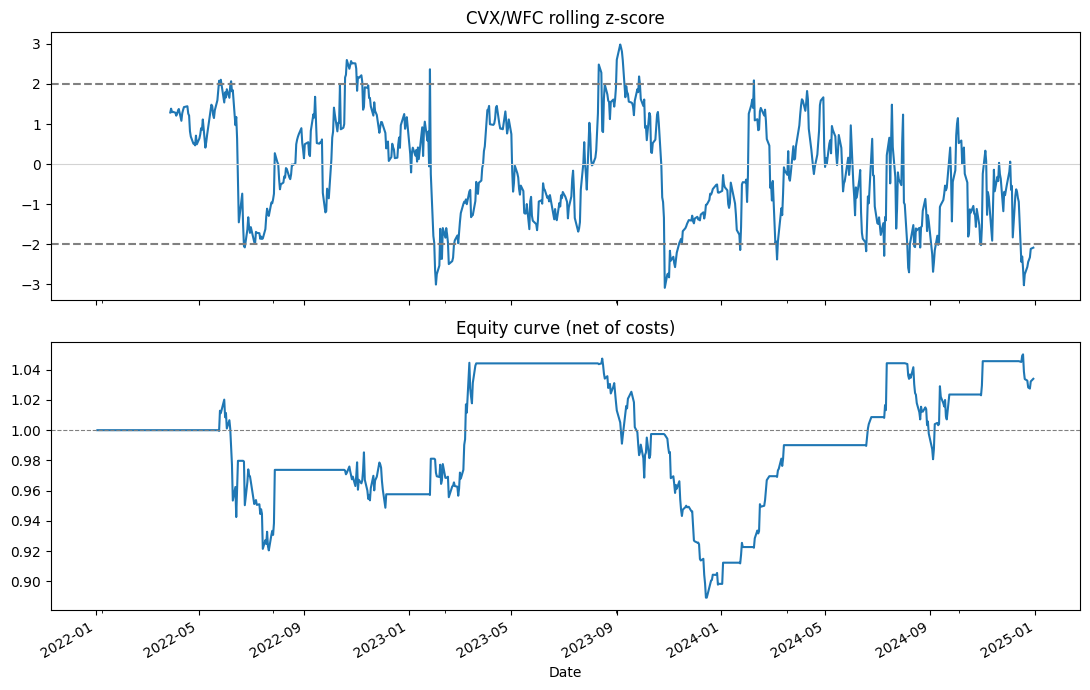

In [11]:
# skip-on-import
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

z.plot(ax=axes[0], title=f"{a}/{b} rolling z-score")
axes[0].axhline(2, ls="--", c="gray")
axes[0].axhline(-2, ls="--", c="gray")
axes[0].axhline(0, ls="-", c="lightgray", lw=0.8)

result["equity"].plot(ax=axes[1], title="Equity curve (net of costs)")
axes[1].axhline(1.0, ls="--", c="gray", lw=0.8)

plt.tight_layout()
plt.savefig(_project_root() / "backtest.png", dpi=120)
plt.show()

## Reading the result

Compare the two tables. The scan ranks pairs by in-sample p-value, but that ranking does **not**
predict which pair actually made money out of sample — the pair with a genuine economic story
usually wins, even when it wasn't ranked first.

Check the out-of-sample p-value column. A pair that passed at 2018-2021 and then fails badly at
2022-2024 is a **regime break**: the relationship stopped existing. That's not a bug, it's the main
risk of this whole strategy, and it's why a stop-loss threshold exists.

Also apply the Bonferroni sanity check: with 66 tests, a genuinely convincing p-value would need to
be below `0.05 / 66 = 0.00076`. Very little clears that bar, which is the honest summary of how much
this scan really proved.

### Pitfalls checklist

| Pitfall | What it is | Defence used here |
|---|---|---|
| Lookahead bias | Using data from after time t | `.rolling()` and `.shift(1)` |
| In-sample selection | Picking the pair on the data you test it on | Separate formation and trading windows |
| Survivorship bias | Universe only contains firms that still exist | Acknowledged; needs point-in-time data to fix |
| Transaction costs | Fees quietly eat the edge | Charged on every position change |
| Regime breaks | Cointegration is a sample property, not a law | Stop-loss; check out-of-sample p-values |